In [59]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

In [60]:
from pyspark.sql import SparkSession
# For Linear Interpolation
from pyspark.sql import Window
import pyspark.sql.functions as F

from pyspark.sql.functions import dayofweek, count
from pyspark.sql.functions import min, max
import holidays

import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec
from pyspark.sql.types import *
from pyspark.sql.types import DoubleType, DateType, IntegerType


##### Data Ingestion


Initialize a Spark session

In [61]:
spark = SparkSession.builder.appName("stocks_forecasting").getOrCreate()

Read the dataset into a PySpark 

In [62]:
df = spark.read.csv('all_stocks_5yr.csv', header=True, inferSchema=True)
df.show(5)

+----------+-----+-----+-----+-----+--------+----+
|      date| open| high|  low|close|  volume|Name|
+----------+-----+-----+-----+-----+--------+----+
|2013-02-08|15.07|15.12|14.63|14.75| 8407500| AAL|
|2013-02-11|14.89|15.01|14.26|14.46| 8882000| AAL|
|2013-02-12|14.45|14.51| 14.1|14.27| 8126000| AAL|
|2013-02-13| 14.3|14.94|14.25|14.66|10259500| AAL|
|2013-02-14|14.94|14.96|13.16|13.99|31879900| AAL|
+----------+-----+-----+-----+-----+--------+----+
only showing top 5 rows


Display schema and sample rows

In [63]:
print("schema:")
df.printSchema()
print("sample rows:")
df.show(5)

schema:
root
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: integer (nullable = true)
 |-- Name: string (nullable = true)

sample rows:
+----------+-----+-----+-----+-----+--------+----+
|      date| open| high|  low|close|  volume|Name|
+----------+-----+-----+-----+-----+--------+----+
|2013-02-08|15.07|15.12|14.63|14.75| 8407500| AAL|
|2013-02-11|14.89|15.01|14.26|14.46| 8882000| AAL|
|2013-02-12|14.45|14.51| 14.1|14.27| 8126000| AAL|
|2013-02-13| 14.3|14.94|14.25|14.66|10259500| AAL|
|2013-02-14|14.94|14.96|13.16|13.99|31879900| AAL|
+----------+-----+-----+-----+-----+--------+----+
only showing top 5 rows


Date range

In [64]:
date_stats = df.agg(F.min("date").alias("min"), F.max("date").alias("max")).collect()[0]
print(f"\nDate Range: {date_stats['min']} → {date_stats['max']}")
print("=" * 55)


Date Range: 2013-02-08 → 2018-02-07


##### Data Cleaning Preprocessing

Handling Missing Values

In [65]:
df.createOrReplaceTempView("stocks") # Create a temporary view for SQL queries

In [66]:
null_analysis_sql = spark.sql("""
    SELECT 
        SUM(CASE WHEN date IS NULL THEN 1 ELSE 0 END) AS null_date,
        SUM(CASE WHEN open IS NULL THEN 1 ELSE 0 END) AS null_open,
        SUM(CASE WHEN high IS NULL THEN 1 ELSE 0 END) AS null_high,
        SUM(CASE WHEN low IS NULL THEN 1 ELSE 0 END) AS null_low,
        SUM(CASE WHEN close IS NULL THEN 1 ELSE 0 END) AS null_close,
        SUM(CASE WHEN volume IS NULL THEN 1 ELSE 0 END) AS null_volume,
        SUM(CASE WHEN Name IS NULL THEN 1 ELSE 0 END) AS null_Name,
        COUNT(*) AS total_rows
    FROM stocks
""")
null_analysis_sql.show()

+---------+---------+---------+--------+----------+-----------+---------+----------+
|null_date|null_open|null_high|null_low|null_close|null_volume|null_Name|total_rows|
+---------+---------+---------+--------+----------+-----------+---------+----------+
|        0|       11|        8|       8|         0|          0|        0|    619040|
+---------+---------+---------+--------+----------+-----------+---------+----------+



Fill Missing Values by Forward Fill

In [67]:
window_spec = Window.partitionBy("Name").orderBy("date")

def fill_nulls(df, column_name):
    # Forward Fill (from the previous value)
    df = df.withColumn(
        column_name, 
        F.last(column_name, True).over(window_spec.rowsBetween(Window.unboundedPreceding, 0))
    )
    return df

for col_name in ["high", "low"]:
    df = fill_nulls(df, col_name)

df = df.withColumn(
    "open", 
    F.coalesce(F.col("open"), F.lag("close", 1).over(window_spec))
)

df = spark.sql("""
    SELECT * FROM stocks 
    WHERE date IS NOT NULL 
      AND open IS NOT NULL 
      AND high IS NOT NULL 
      AND low IS NOT NULL 
      AND close IS NOT NULL 
      AND volume IS NOT NULL 
      AND Name IS NOT NULL
""")

df.createOrReplaceTempView("stocks")

spark.sql("SELECT COUNT(*) FROM stocks WHERE open IS NULL").show()

+--------+
|count(1)|
+--------+
|       0|
+--------+



Handling Duplicates

In [68]:
duplicate_check = spark.sql("""
    SELECT date, Name, COUNT(*) as occurrence
    FROM stocks
    GROUP BY date, Name
    HAVING COUNT(*) > 1
""")

duplicate_check.show()
print(f"Number of duplicate: {duplicate_check.count()}")

+----+----+----------+
|date|Name|occurrence|
+----+----+----------+
+----+----+----------+



Number of duplicate: 0


Handling Outliers

In [69]:
quantiles = df.approxQuantile("volume", [0.25, 0.75], 0.01)

# IQR = Q3 -Q1
IQR = quantiles[1] - quantiles[0]

# Upper bound = Q3 + 1.5 * IQR
upper_bound = quantiles[1] + 1.5 * IQR
# Lower bound = Q1 - 1.5 * IQR
lower_bound = quantiles[0] - 1.5 * IQR

outliers_df = df.filter((F.col("volume") > upper_bound) | (F.col("volume") < lower_bound))
outliers_count = outliers_df.count()
total_count = df.count()

print(f"Total Rows: {total_count}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of Outliers detected: {outliers_count}")
print(f"Percentage of Outliers: {(outliers_count / total_count) * 100:.2f}%")

Total Rows: 619029
Lower Bound: -3669163.0
Upper Bound: 8935141.0
Number of Outliers detected: 61100
Percentage of Outliers: 9.87%


Ensuring Dataset Contains Only Stock Market Business Days (Mon–Fri)

In [70]:
df_check = df.withColumn("day_num", dayofweek("date")) # 1 = Sunday, 2 = Monday, ..., 7 = Saturday

weekend_analysis = df_check.groupBy("day_num").agg(count("*").alias("record_count")).orderBy("day_num")

weekend_analysis.show()

+-------+------------+
|day_num|record_count|
+-------+------------+
|      2|      115998|
|      3|      127827|
|      4|      127376|
|      5|      123922|
|      6|      123906|
+-------+------------+



In [71]:
df.coalesce(1).write.mode("overwrite").option("header", "true").csv("cleaned_stocks_data.csv")

Calendar & Time-Series Feature Engineering

In [72]:
dt = df["date"].dt

In [73]:
# Basic calendar
df = df.withColumn("date", F.to_date(F.col("date")))

df = df.withColumn("year", F.year(F.col("date"))) \
       .withColumn("month", F.month(F.col("date"))) \
       .withColumn("day", F.dayofmonth(F.col("date"))) \
       .withColumn("dayofweek", F.dayofweek(F.col("date"))) \
       .withColumn("quarter", F.quarter(F.col("date"))) \
       .withColumn("weekofyear", F.weekofyear(F.col("date")))

df = df.withColumn("day_name", F.date_format(F.col("date"), "EEEE"))

In [74]:
# Weekend / Weekday
df = df.withColumn(
    "is_weekend",
    F.when(F.col("dayofweek").isin([6, 7]), 1).otherwise(0)
)
df = df.withColumn("is_weekday", (1 - F.col("is_weekend")))

In [75]:
# Month start / end
df = df.withColumn("is_month_start", F.when(F.col("day") == 1, 1).otherwise(0))
df = df.withColumn(
    "is_month_end",
    F.when(
        F.col("day") == F.dayofmonth(F.last_day("date")), 1
    ).otherwise(0)
)


In [76]:
# Quarter start / end 
df = df.withColumn(
    "is_quarter_start",
    F.when(
        (F.col("month").isin([1, 4, 7, 10])) & (F.col("day") == 1), 1
    ).otherwise(0)
)
df = df.withColumn(
    "is_quarter_end",
    F.when(
        ((F.col("month") == 3)  & (F.col("day") == 31)) |
        ((F.col("month") == 6)  & (F.col("day") == 30)) |
        ((F.col("month") == 9)  & (F.col("day") == 30)) |
        ((F.col("month") == 12) & (F.col("day") == 31)), 1
    ).otherwise(0)
)


In [77]:
# Year start / end
df = df.withColumn(
    "is_year_start",
    F.when((F.col("month") == 1)  & (F.col("day") == 1),  1).otherwise(0)
)
df = df.withColumn(
    "is_year_end",
    F.when((F.col("month") == 12) & (F.col("day") == 31), 1).otherwise(0)
)

In [78]:
# Holidays
us_holidays = holidays.US(years=range(2013, 2019))

holiday_list = [(h,) for h in us_holidays.keys()] # قائمة بـ tuples فيها التاريخ
holiday_df = spark.createDataFrame(holiday_list, ["holiday_date"])

df = df.withColumn("date_formatted", F.to_date(F.col("date")))

df = df.join(
    F.broadcast(holiday_df),
    df.date_formatted == holiday_df.holiday_date,
    "left"
)

df = df.withColumn(
    "is_holiday", 
    F.when(F.col("holiday_date").isNotNull(), 1).otherwise(0)
).drop("holiday_date", "date_formatted")

In [79]:
# TIME-BETWEEN-EVENTS  (days since previous row per stock)
window_stock = Window.partitionBy("Name").orderBy("date")
 
df = df.withColumn(
    "days_since_prev",
    F.datediff(
        F.col("date"),
        F.lag("date", 1).over(window_stock)
    )
)


In [80]:
# LAG FEATURES  (previous closing prices within the same stock)
LAG_PERIODS = [1, 2, 3]
 
for lag in LAG_PERIODS:
    df = df.withColumn(
        f"lag_{lag}",
        F.lag("close", lag).over(window_stock)
)

In [81]:
# for test the result
df.show(1000)


+----------+-------+--------+--------+-------+---------+----+----+-----+---+---------+-------+----------+---------+----------+----------+--------------+------------+----------------+--------------+-------------+-----------+----------+---------------+-------+-------+-------+
|      date|   open|    high|     low|  close|   volume|Name|year|month|day|dayofweek|quarter|weekofyear| day_name|is_weekend|is_weekday|is_month_start|is_month_end|is_quarter_start|is_quarter_end|is_year_start|is_year_end|is_holiday|days_since_prev|  lag_1|  lag_2|  lag_3|
+----------+-------+--------+--------+-------+---------+----+----+-----+---+---------+-------+----------+---------+----------+----------+--------------+------------+----------------+--------------+-------------+-----------+----------+---------------+-------+-------+-------+
|2013-02-08|67.7142| 68.4014| 66.8928|67.8542|158168416|AAPL|2013|    2|  8|        6|      1|         6|   Friday|         1|         0|             0|           0|          

In [82]:
df.coalesce(1).write.mode("overwrite").parquet("stocks_after_fe.parquet")

##### Data Analyst: Exploration & Insights

### Story
With clean data in hand, the Data Analyst explores the landscape — looking for patterns, anomalies, and opportunities. We'll examine **how trading volume (demand) behaves** across time, stocks, and market conditions.

**Key Questions:**
1. How has overall market demand evolved over 5 years?
2. Which stocks dominate by trading volume?
3. Are there seasonal patterns in demand?
4. How does price correlate with volume?


In [83]:
# Plotting style
plt.rcParams['figure.facecolor'] = '#0f1117'
plt.rcParams['axes.facecolor'] = '#1a1d2e'
plt.rcParams['axes.edgecolor'] = '#444'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#333'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['font.family'] = 'DejaVu Sans'

COLORS = ['#00d4ff', '#ff6b6b', '#ffd93d', '#6bcb77', '#c77dff',
          '#f4845f', '#48cae4', '#e9c46a', '#2a9d8f', '#e76f51']


In [84]:
from pyspark.sql.types import DoubleType, DateType
import pyspark.sql.functions as F

# 1. Convert columns to DoubleType to handle decimals, and DateType for date column
cols_to_convert = ["open", "high", "low", "close", "volume"]

for col_name in cols_to_convert:
    df = df.withColumn(col_name, F.col(col_name).cast(DoubleType()))

# Ensure the date column is in Date format
df = df.withColumn("date", F.to_date(F.col("date")))

# 2. Cleaning Pipeline
df_clean = df \
    .dropna(subset=["close", "volume", "Name", "date"]) \
    .filter(F.col("volume") > 0) \
    .filter(F.col("close") > 0) \
    .filter(F.col("open") > 0) \
    .withColumn("Name", F.upper(F.trim(F.col("Name")))) \
    .dropDuplicates(["date", "Name"])

# 3. Feature Engineering - Date parts
df_clean = df \
    .withColumn("year", F.year("date")) \
    .withColumn("month", F.month("date")) \
    .withColumn("quarter", F.quarter("date")) \
    .withColumn("dayofweek", F.dayofweek("date")) \
    .withColumn("dayofyear", F.dayofyear("date"))

# Print success message and show data
print("✅ Cleaning and Feature Engineering completed successfully.")
df_clean.show(5)

✅ Cleaning and Feature Engineering completed successfully.


+----------+-------+-------+-------+-------+------------+----+----+-----+---+---------+-------+----------+---------+----------+----------+--------------+------------+----------------+--------------+-------------+-----------+----------+---------------+-------+-------+-------+---------+
|      date|   open|   high|    low|  close|      volume|Name|year|month|day|dayofweek|quarter|weekofyear| day_name|is_weekend|is_weekday|is_month_start|is_month_end|is_quarter_start|is_quarter_end|is_year_start|is_year_end|is_holiday|days_since_prev|  lag_1|  lag_2|  lag_3|dayofyear|
+----------+-------+-------+-------+-------+------------+----+----+-----+---+---------+-------+----------+---------+----------+----------+--------------+------------+----------------+--------------+-------------+-----------+----------+---------------+-------+-------+-------+---------+
|2013-02-08|67.7142|68.4014|66.8928|67.8542|1.58168416E8|AAPL|2013|    2|  8|        6|      1|         6|   Friday|         1|         0|    

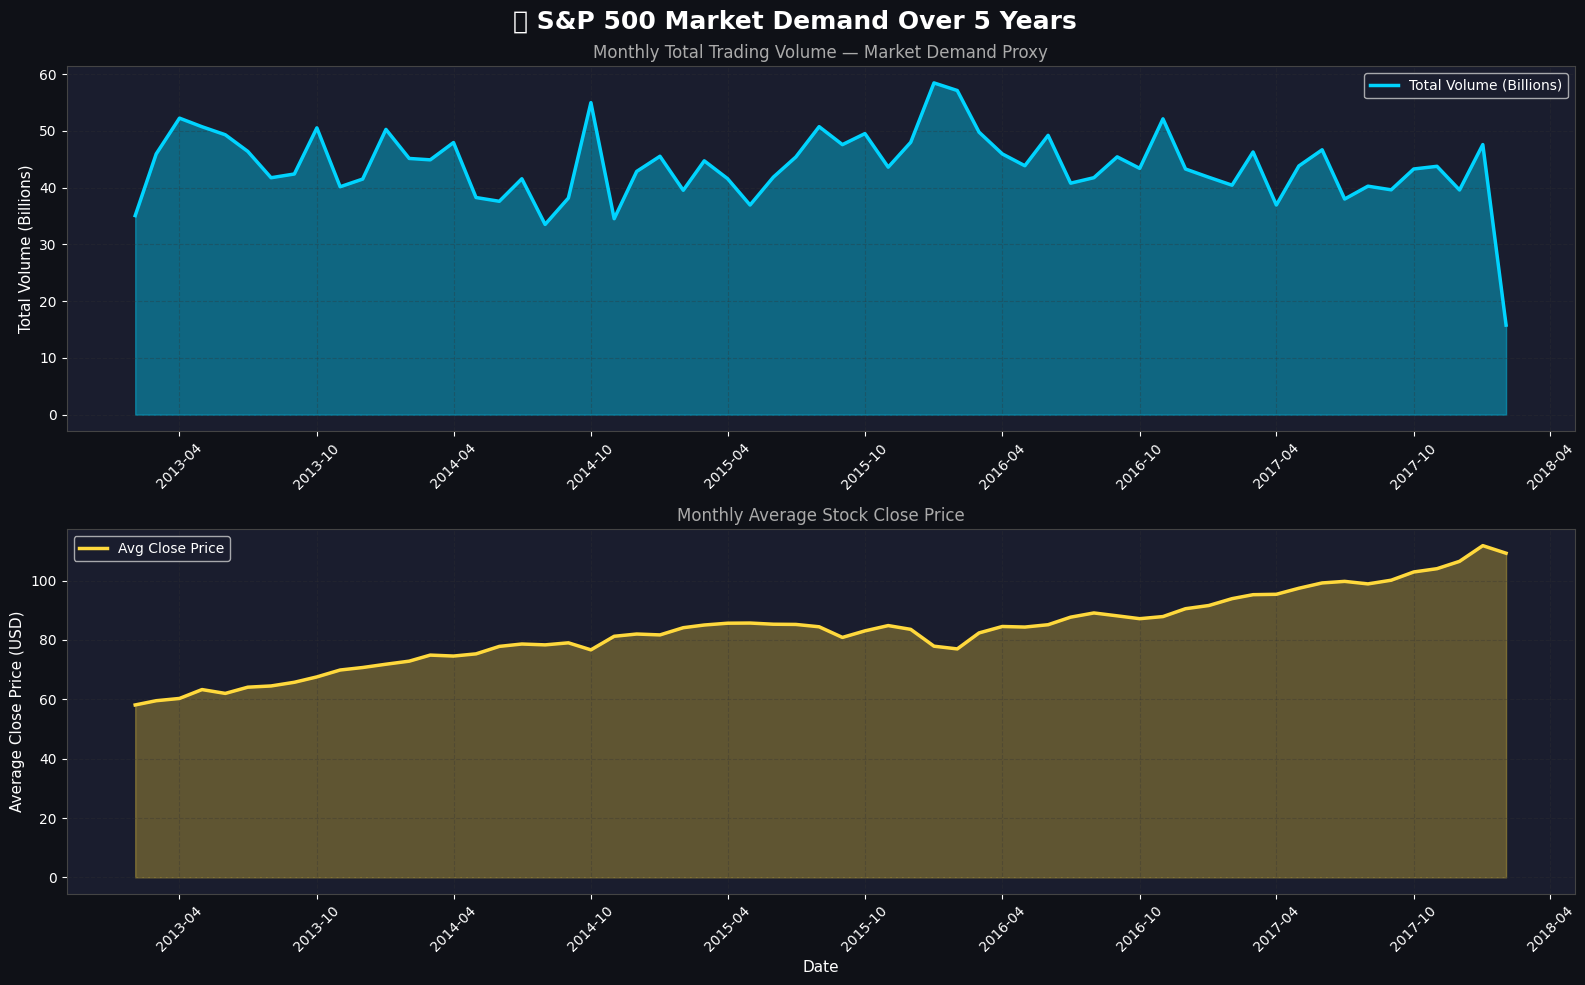

✅ Plot 1 saved


In [85]:
# ── 2.1 Aggregate: monthly market volume (demand)
monthly_vol = df_clean \
    .groupBy("year","month") \
    .agg(F.sum("volume").alias("total_volume"),
         F.avg("close").alias("avg_close"),
         F.countDistinct("Name").alias("active_stocks")) \
    .withColumn("ym", F.concat(F.col("year"), F.lit("-"), F.lpad(F.col("month"),2,"0"))) \
    .orderBy("year","month") \
    .toPandas()

monthly_vol["date"] = pd.to_datetime(monthly_vol["ym"])

# ── Plot 1: Total market volume over time
fig, axes = plt.subplots(2, 1, figsize=(16, 10), facecolor='#0f1117')
fig.suptitle("📈 S&P 500 Market Demand Over 5 Years", fontsize=18, fontweight='bold', color='white', y=0.98)

ax1 = axes[0]
ax1.fill_between(monthly_vol["date"], monthly_vol["total_volume"]/1e9,
                 alpha=0.4, color='#00d4ff')
ax1.plot(monthly_vol["date"], monthly_vol["total_volume"]/1e9,
         color='#00d4ff', linewidth=2.5, label="Total Volume (Billions)")
ax1.set_ylabel("Total Volume (Billions)", fontsize=11)
ax1.set_title("Monthly Total Trading Volume — Market Demand Proxy", fontsize=12, color='#aaa')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

ax2 = axes[1]
ax2.plot(monthly_vol["date"], monthly_vol["avg_close"],
         color='#ffd93d', linewidth=2.5, label="Avg Close Price")
ax2.fill_between(monthly_vol["date"], monthly_vol["avg_close"],
                 alpha=0.3, color='#ffd93d')
ax2.set_ylabel("Average Close Price (USD)", fontsize=11)
ax2.set_xlabel("Date", fontsize=11)
ax2.set_title("Monthly Average Stock Close Price", fontsize=12, color='#aaa')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig("/tmp/plot1_market_overview.png", dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("✅ Plot 1 saved")


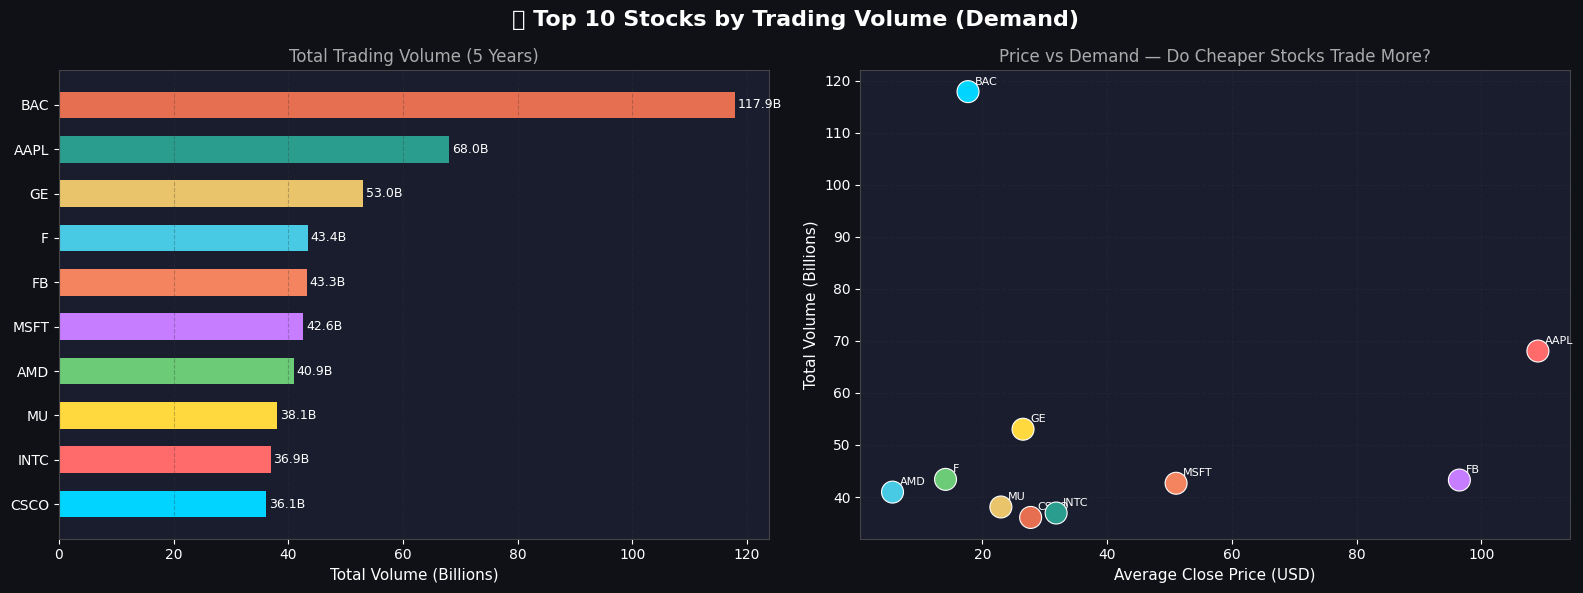

✅ Plot 2 saved


In [86]:
# ── 2.2 Top 10 stocks by total volume
top_stocks = df_clean \
    .groupBy("Name") \
    .agg(F.sum("volume").alias("total_volume"),
         F.avg("close").alias("avg_close"),
         F.stddev("volume").alias("vol_std")) \
    .orderBy(F.desc("total_volume")) \
    .limit(10) \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0f1117')
fig.suptitle("🏆 Top 10 Stocks by Trading Volume (Demand)", fontsize=16, fontweight='bold', color='white')

# Bar chart
ax = axes[0]
bars = ax.barh(top_stocks["Name"][::-1], top_stocks["total_volume"][::-1]/1e9,
               color=COLORS[:10], edgecolor='none', height=0.6)
for bar, val in zip(bars, top_stocks["total_volume"][::-1]/1e9):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}B", va='center', fontsize=9, color='white')
ax.set_xlabel("Total Volume (Billions)", fontsize=11)
ax.set_title("Total Trading Volume (5 Years)", fontsize=12, color='#aaa')
ax.grid(axis='x', alpha=0.3)

# Scatter: avg price vs volume
ax2 = axes[1]
scatter = ax2.scatter(top_stocks["avg_close"], top_stocks["total_volume"]/1e9,
                      c=COLORS[:len(top_stocks)], s=250, zorder=5, edgecolors='white', linewidths=0.8)
for _, row in top_stocks.iterrows():
    ax2.annotate(row["Name"],
                 xy=(row["avg_close"], row["total_volume"]/1e9),
                 xytext=(5, 5), textcoords="offset points",
                 fontsize=8, color='white')
ax2.set_xlabel("Average Close Price (USD)", fontsize=11)
ax2.set_ylabel("Total Volume (Billions)", fontsize=11)
ax2.set_title("Price vs Demand — Do Cheaper Stocks Trade More?", fontsize=12, color='#aaa')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/plot2_top_stocks.png", dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Plot 2 saved")


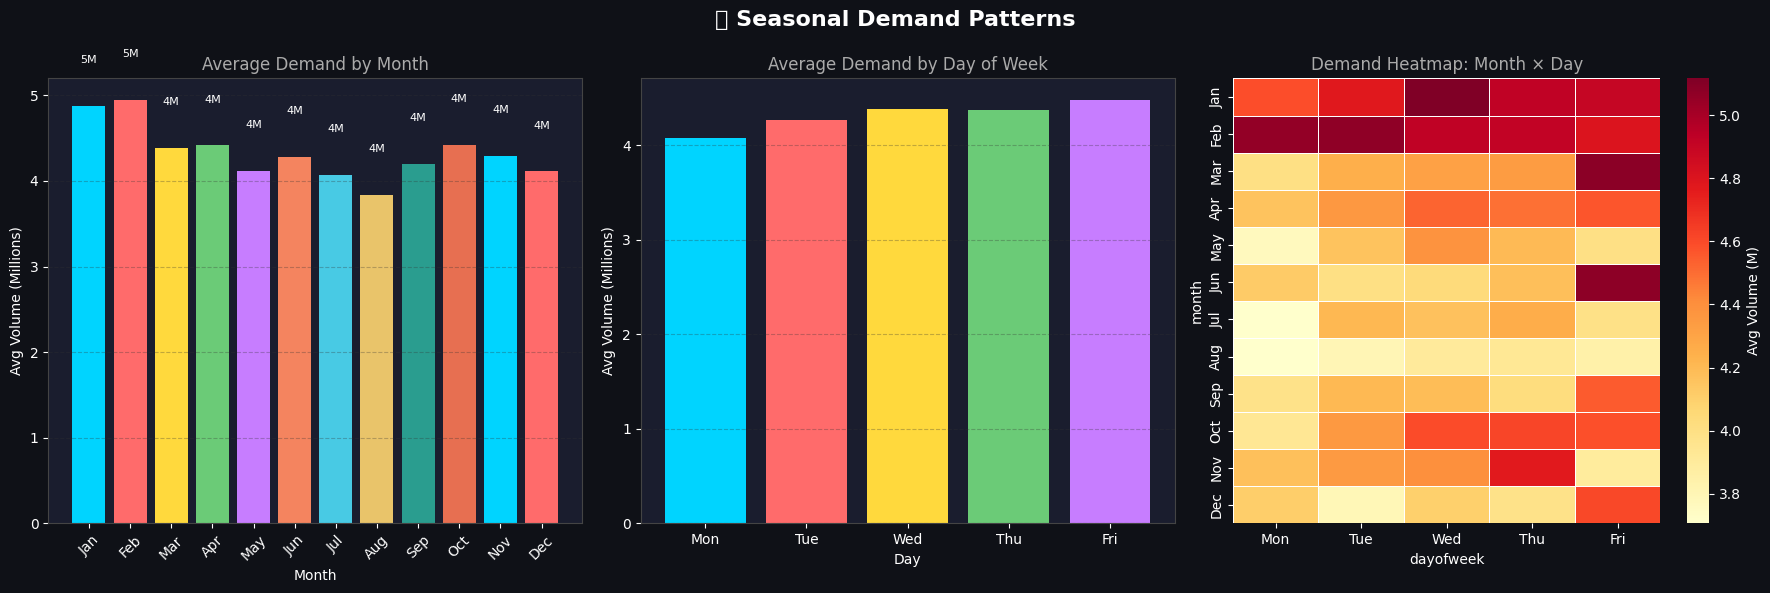

✅ Plot 3 saved


In [87]:
# ── 2.3 Seasonal Analysis — Month & Day-of-Week patterns
seasonal = df_clean \
    .groupBy("month","dayofweek") \
    .agg(F.avg("volume").alias("avg_volume")) \
    .toPandas()

monthly_avg = df_clean.groupBy("month").agg(F.avg("volume").alias("avg_vol")).orderBy("month").toPandas()
dow_avg     = df_clean.groupBy("dayofweek").agg(F.avg("volume").alias("avg_vol")).orderBy("dayofweek").toPandas()

month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
dow_names   = ["Sun","Mon","Tue","Wed","Thu","Fri","Sat"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#0f1117')
fig.suptitle("🗓️ Seasonal Demand Patterns", fontsize=16, fontweight='bold', color='white')

# Monthly
ax = axes[0]
x = monthly_avg["month"].values - 1
y = monthly_avg["avg_vol"].values / 1e6
ax.bar([month_names[i] for i in x], y, color=COLORS[:12], edgecolor='none')
ax.set_title("Average Demand by Month", fontsize=12, color='#aaa')
ax.set_ylabel("Avg Volume (Millions)", fontsize=10)
ax.set_xlabel("Month", fontsize=10)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(axis='y', alpha=0.3)
for i, (xi, yi) in enumerate(zip(ax.get_xticks(), y)):
    ax.text(xi, yi + 0.5, f"{yi:.0f}M", ha='center', fontsize=8, color='white')

# Day of week
ax2 = axes[1]
x2 = dow_avg["dayofweek"].values - 1
y2 = dow_avg["avg_vol"].values / 1e6
labels = [dow_names[i] if i < 7 else "?" for i in x2]
ax2.bar(labels, y2, color=COLORS[:7], edgecolor='none')
ax2.set_title("Average Demand by Day of Week", fontsize=12, color='#aaa')
ax2.set_ylabel("Avg Volume (Millions)", fontsize=10)
ax2.set_xlabel("Day", fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Heatmap — month x dow
pivot = seasonal.pivot_table(index="month", columns="dayofweek", values="avg_volume")
ax3 = axes[2]
sns.heatmap(pivot/1e6, ax=ax3, cmap="YlOrRd", linewidths=0.5,
            xticklabels=[dow_names[i-1] if i-1 < 7 else str(i) for i in pivot.columns],
            yticklabels=[month_names[i-1] for i in pivot.index],
            cbar_kws={"label": "Avg Volume (M)"})
ax3.set_title("Demand Heatmap: Month × Day", fontsize=12, color='#aaa')

plt.tight_layout()
plt.savefig("/tmp/plot3_seasonal.png", dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Plot 3 saved")


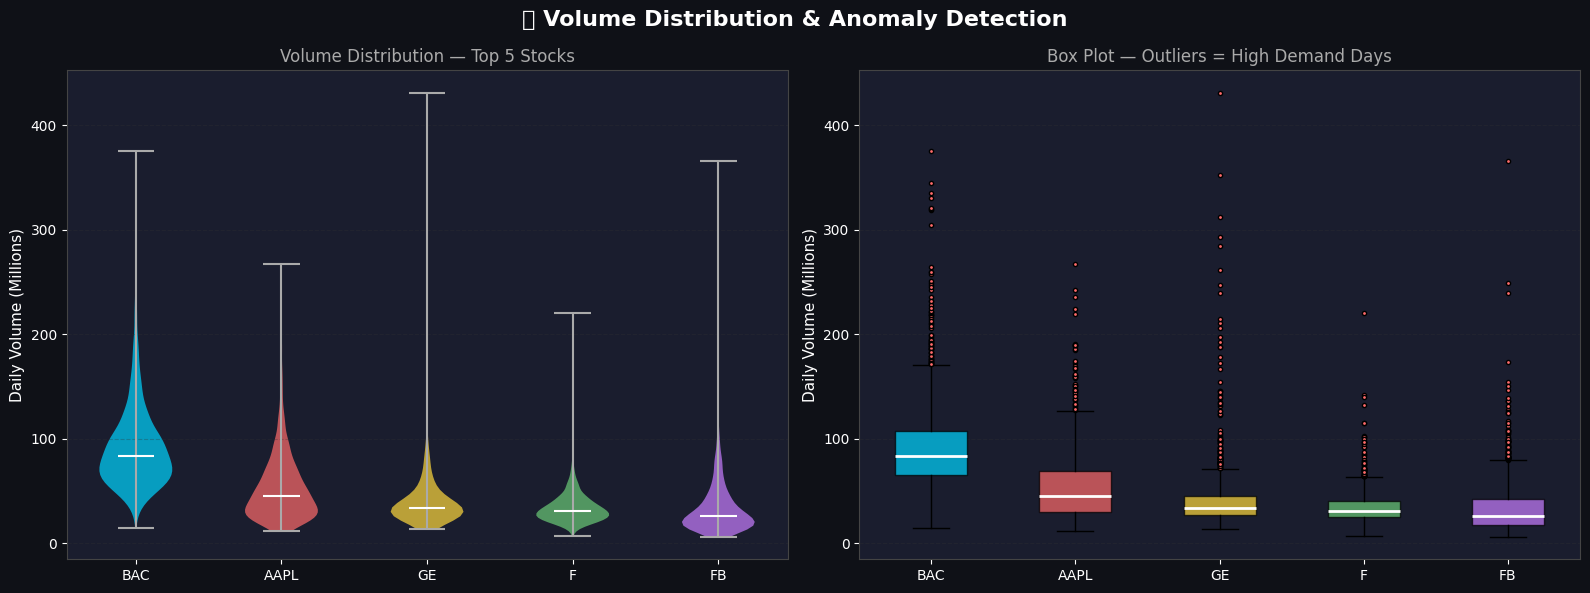

✅ Plot 4 saved


In [88]:
# ── 2.4 Volume Distribution & Outlier Analysis
top5 = [r["Name"] for r in df_clean.groupBy("Name").agg(F.sum("volume").alias("tv"))
        .orderBy(F.desc("tv")).limit(5).collect()]

sample_df = df_clean.filter(F.col("Name").isin(top5)).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0f1117')
fig.suptitle("📊 Volume Distribution & Anomaly Detection", fontsize=16, fontweight='bold', color='white')

# Violin plot
ax = axes[0]
parts = ax.violinplot(
    [sample_df[sample_df["Name"]==t]["volume"].values/1e6 for t in top5],
    positions=range(len(top5)),
    showmedians=True, showextrema=True
)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(COLORS[i])
    pc.set_alpha(0.7)
parts['cmedians'].set_color('white')
parts['cmins'].set_color('#aaa')
parts['cmaxes'].set_color('#aaa')
parts['cbars'].set_color('#aaa')
ax.set_xticks(range(len(top5)))
ax.set_xticklabels(top5)
ax.set_ylabel("Daily Volume (Millions)", fontsize=11)
ax.set_title("Volume Distribution — Top 5 Stocks", fontsize=12, color='#aaa')
ax.grid(axis='y', alpha=0.3)

# Box plot with outliers
ax2 = axes[1]
data_list = [sample_df[sample_df["Name"]==t]["volume"].values/1e6 for t in top5]
bp = ax2.boxplot(data_list, labels=top5, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor='#ff6b6b', markersize=3))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel("Daily Volume (Millions)", fontsize=11)
ax2.set_title("Box Plot — Outliers = High Demand Days", fontsize=12, color='#aaa')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/plot4_distribution.png", dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Plot 4 saved")


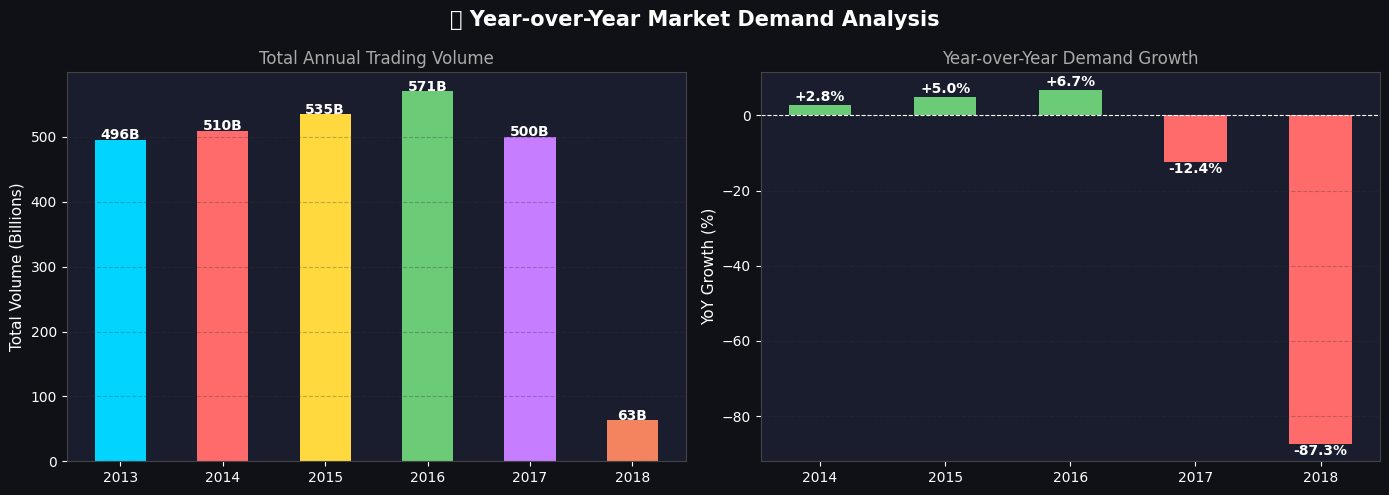

✅ Plot 5 saved


In [89]:
# ── 2.5 Year-over-Year Demand Growth
yoy = df_clean.groupBy("year") \
    .agg(F.sum("volume").alias("total_vol"),
         F.avg("close").alias("avg_price")) \
    .orderBy("year") \
    .toPandas()

yoy["vol_growth"] = yoy["total_vol"].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0f1117')
fig.suptitle("📅 Year-over-Year Market Demand Analysis", fontsize=15, fontweight='bold', color='white')

ax = axes[0]
bars = ax.bar(yoy["year"].astype(str), yoy["total_vol"]/1e9,
              color=COLORS[:len(yoy)], edgecolor='none', width=0.5)
for bar, val in zip(bars, yoy["total_vol"]/1e9):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f"{val:.0f}B", ha='center', fontsize=10, color='white', fontweight='bold')
ax.set_ylabel("Total Volume (Billions)", fontsize=11)
ax.set_title("Total Annual Trading Volume", fontsize=12, color='#aaa')
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
growth = yoy.dropna(subset=["vol_growth"])
colors_g = ['#6bcb77' if v >= 0 else '#ff6b6b' for v in growth["vol_growth"]]
ax2.bar(growth["year"].astype(str), growth["vol_growth"],
        color=colors_g, edgecolor='none', width=0.5)
ax2.axhline(0, color='white', linewidth=0.8, linestyle='--')
for i, (yr, val) in enumerate(zip(growth["year"], growth["vol_growth"])):
    ax2.text(i, val + (1 if val >= 0 else -3),
             f"{val:+.1f}%", ha='center', fontsize=10, color='white', fontweight='bold')
ax2.set_ylabel("YoY Growth (%)", fontsize=11)
ax2.set_title("Year-over-Year Demand Growth", fontsize=12, color='#aaa')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/plot5_yoy.png", dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Plot 5 saved")
